In [ ]:
import pandas as pd
import pyodbc
Cadena = (
    f'Driver={{ODBC Driver 17 for SQL Server}};'
    f'Server={r'M027599\SQLEXPRESS'};' #Este lo copiamos dando click derecho al server que tenemos en el programa de SQL y copiando lo que vemos en Propiedades
    f'Database={'Neptuno'};'
    f'Trusted_Connection={'yes'};'
)

Conexion = pyodbc.connect(Cadena)

In [ ]:
import sqlparse
codesql = """SELECT        SUM(Detalles_de_pedidos.PrecioUnidad * Detalles_de_pedidos.Cantidad) AS Importe, Categorías.NombreCategoría AS Categorías, COUNT(Pedidos.PaísDestinatario) AS NumPedidos
FROM            Pedidos INNER JOIN
                         Detalles_de_pedidos ON Pedidos.IdPedido = Detalles_de_pedidos.IdPedido INNER JOIN
                         Productos ON Detalles_de_pedidos.IdProducto = Productos.IdProducto INNER JOIN
                         Categorías ON Productos.IdCategoría = Categorías.IdCategoría
GROUP BY Categorías.NombreCategoría"""

codelimpio = sqlparse.format(
    codesql, 
    reindent=True, 
    keyword_case="upper"
)

resultado = print(codelimpio)

agrupado = pd.read_sql(codelimpio, Conexion)
agrupado

<Figure size 1200x500 with 0 Axes>

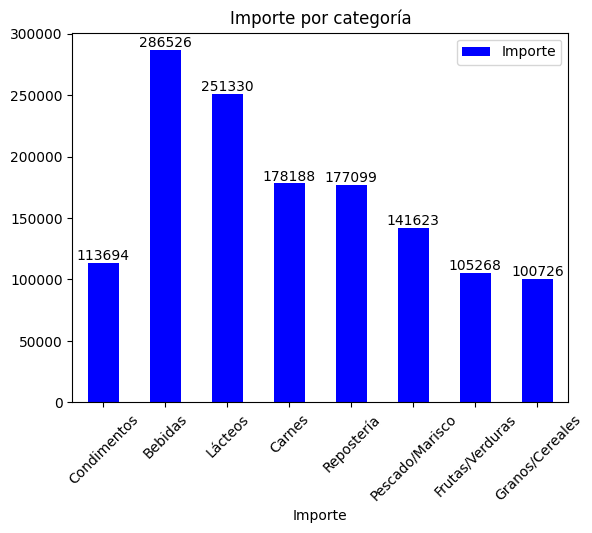

In [79]:
import matplotlib.pyplot as plt
#Vamos a crear la figura reservando espacio en el kernel
plt.figure(figsize=(12,5)) #en figsize primero el ancho y después el alto
#A través del dataframe que tenemos cargado, "agrupado", llamamos al método plot para imprimir
agrupado.plot(kind="bar", x="Categorías", y="Importe", color="blue") #kind es igual al tipo de gráfico, recordar lección anterior
#Configuraciones adicionales
plt.title("Importe por categoría") #le ponemos un título al gráfico
plt.xlabel("Categorías") #el título del eje de las x
plt.xlabel("Importe") #el título del eje de las y
plt.xticks(rotation=45) #con esto rotamos el eje x, para tener una visión más clara que no las letras en vertical
#Vamos a poner mediante un bucle los importes en cada columna
agrupado["Importe"] = agrupado["Importe"].astype(int) #Esta parte es para redondear, quitando los decimales. Más bien estética
for i, v in enumerate(agrupado["Importe"]):
    plt.text(i,v,f"{v}",ha="center",va="bottom")
    
plt.show() #esto muestra el gráfico en el output

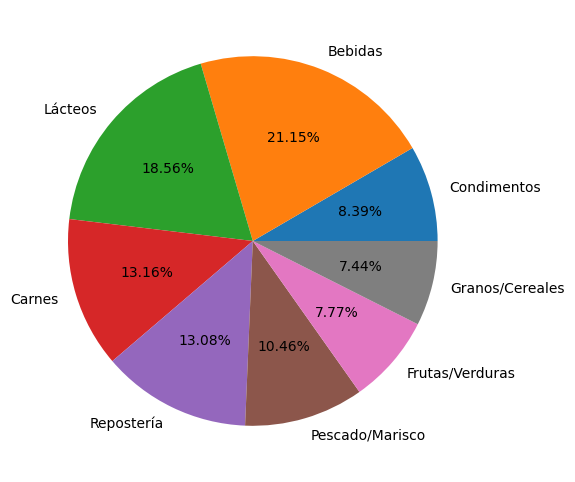

In [48]:
#Gráfico circular sería el kind="pie", el figsize tiene que ser cuadrado
plt.figure(figsize=(6,6)) #dimensionamos un cuadradito
plt.pie(x=agrupado["Importe"], labels=agrupado["Categorías"], autopct="%1.2f%%") #el autopct es para decirle un formato, que empieza por porcentaje y acaba por porcentaje
#el 1 indica la parte entera, el punto la decimal y el dos el número de decimales que quiero... y el otro signo de porcentaje, pues eso, que salga el signo
plt.show()

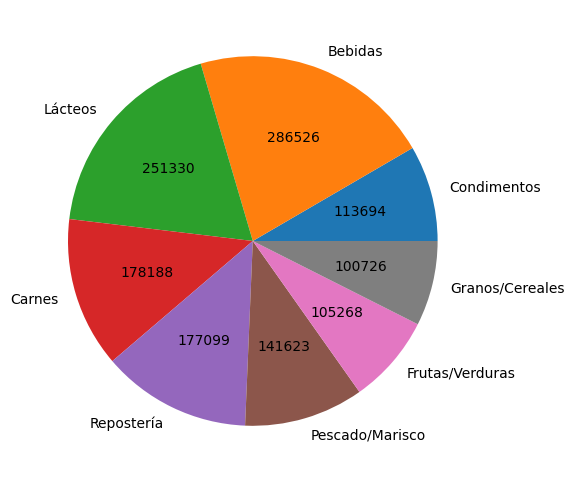

In [ ]:
#Ver en el gráfico circular la suma de importe por categoría en valor absoluto
plt.figure(figsize=(6,6))
#Una función para el parámetro autopct
def mostrarimportes(valor):
    def formato(pct):
        total=sum(valor)
        resultado=int(round(pct*total/100)) #esto nos daría la cantidad relativa de cada facción en términos absolutos
        return f"{resultado}"
    return formato

plt.pie(x=agrupado["Importe"], labels=agrupado["Categorías"], autopct=mostrarimportes(agrupado["Importe"]))
plt.show()



In [59]:
#Queremos ver las 3 categorías que más importe venden y ver su % con respecto al total
agrupadotop3 = agrupado.nlargest(3, "Importe")
agrupadotop3

,Importe,Categorías,NumPedidos
1,286526,Bebidas,404
2,251330,Lácteos,366
3,178188,Carnes,173


In [ ]:
#Ahora vemos los más bajos
agrupadoresto = agrupado.nsmallest(agrupado["Importe"].count()-3, "Importe")
agrupadoresto

,Importe,Categorías,NumPedidos
7,100726,Granos/Cereales,196
6,105268,Frutas/Verduras,136
0,113694,Condimentos,216
5,141623,Pescado/Marisco,330
4,177099,Repostería,334


In [ ]:
#Calculamos cuánto sería el total
importeresto=agrupadoresto["Importe"].sum()
importeresto

np.int64(638410)

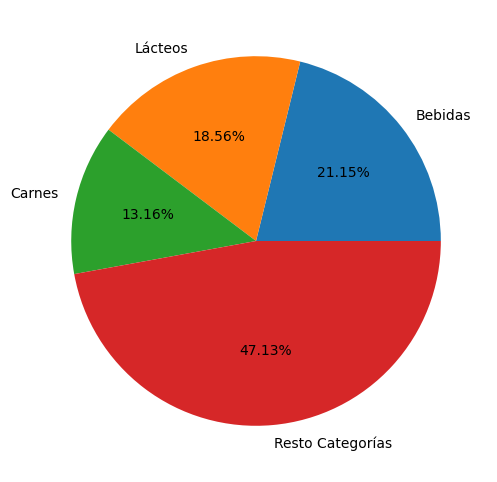

In [ ]:
#Crear un dataframe de una sola linea
impcat = pd.DataFrame([
    {"Categorías":"Resto Categorías", "Importe":importeresto}
])
impcat
#Y unimos esto al top 3, concatenando ambos dataframes
agrupadofinal = pd.concat([agrupadotop3, impcat], ignore_index=True)
agrupadofinal
#Ver el gráfico
plt.figure(figsize=(6,6)) #dimensionamos un cuadradito
plt.pie(x=agrupadofinal["Importe"], labels=agrupadofinal["Categorías"], autopct="%1.2f%%") #el autopct es para decirle un formato, que empieza por porcentaje y acaba por porcentaje
#el 1 indica la parte entera, el punto la decimal y el dos el número de decimales que quiero... y el otro signo de porcentaje, pues eso, que salga el signo
plt.show()

PRÁCTICA 39: Partiendo del dataframe que contiene la suma de importe + número de pedidos por categoría:
- Añadir una nueva categoría, "Comida Mascotas", que tiene 384 pedidos, por un importe de 354267
- Ver en un gráfico de barras color azul las cinco categorías que menos importe tienen
- Ver en un gráfico circular el porcentaje de las cuatro categorías que más números de pedidos tienen (cuidado con el resto), formateado en valor relativo

In [73]:
import sqlparse
codesql = """SELECT        SUM(Detalles_de_pedidos.PrecioUnidad * Detalles_de_pedidos.Cantidad) AS Importe, Categorías.NombreCategoría AS Categorías, COUNT(Pedidos.PaísDestinatario) AS NumPedidos
FROM            Pedidos INNER JOIN
                         Detalles_de_pedidos ON Pedidos.IdPedido = Detalles_de_pedidos.IdPedido INNER JOIN
                         Productos ON Detalles_de_pedidos.IdProducto = Productos.IdProducto INNER JOIN
                         Categorías ON Productos.IdCategoría = Categorías.IdCategoría
GROUP BY Categorías.NombreCategoría"""

codelimpio = sqlparse.format(
    codesql, 
    reindent=True, 
    keyword_case="upper"
)

resultado = print(codelimpio)

agrupado = pd.read_sql(codelimpio, Conexion)
agrupado

SELECT SUM(Detalles_de_pedidos.PrecioUnidad * Detalles_de_pedidos.Cantidad) AS Importe,
       Categorías.NombreCategoría AS Categorías,
       COUNT(Pedidos.PaísDestinatario) AS NumPedidos
FROM Pedidos
INNER JOIN Detalles_de_pedidos ON Pedidos.IdPedido = Detalles_de_pedidos.IdPedido
INNER JOIN Productos ON Detalles_de_pedidos.IdProducto = Productos.IdProducto
INNER JOIN Categorías ON Productos.IdCategoría = Categorías.IdCategoría
GROUP BY Categorías.NombreCategoría


C:\Users\formacio\AppData\Local\Temp\ipykernel_4960\2711845733.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  agrupado = pd.read_sql(codelimpio, Conexion)


,Importe,Categorías,NumPedidos
0,113694.75,Condimentos,216
1,286526.95,Bebidas,404
2,251330.50,Lácteos,366
3,178188.80,Carnes,173
4,177099.10,Repostería,334
5,141623.09,Pescado/Marisco,330
6,105268.60,Frutas/Verduras,136
7,100726.80,Granos/Cereales,196


In [114]:
import pandas as pd

novacat = pd.DataFrame([
    {"Importe":"354267", "Categorías":"Comida Mascotas","NumPedidos":384}
])
novacat

agrupadoausar = pd.concat([agrupado, novacat], ignore_index=True)
agrupadoausar


,Importe,Categorías,NumPedidos
0,113694,Condimentos,216
1,286526,Bebidas,404
2,251330,Lácteos,366
3,178188,Carnes,173
4,177099,Repostería,334
5,141623,Pescado/Marisco,330
6,105268,Frutas/Verduras,136
7,100726,Granos/Cereales,196
8,354267,Comida Mascotas,384
9,354267,Comida Mascotas,384


In [117]:
agrupadoausar["Importe"] = agrupadoausar["Importe"].astype(float)

agrupado5 = agrupadoausar.nsmallest(5, "Importe")
agrupadoresto = agrupadoausar.nlargest(agrupadoausar["Importe"].count()-5, "Importe")
importeresto = agrupadoresto["Importe"].sum()
pedidoresto = agrupadoresto["NumPedidos"].sum()

In [120]:
#Creamos el dataframe del resto
agrupadoresto2 = pd.DataFrame([
    {"Importe":importeresto, "Categorías":"Resto Categorías","NumPedidos":pedidoresto}
])

Machine Learning
- Supervisado (clasificación, regresión)
- No supervisado (clustering)
Dataset: features (x) - target (y), donde "y" es el valor a predecir
- Overfitting/Underfitting
- Train/Test split
- Métricas básicas
-- accuracy
-- MAE/MSE

Algoritmos:
- Regresión lineal
- KNN 
- Árboles de decisión
- y un largo etc

REGRESIÓN LINEAL es la relación entre dos variables cuantitativas consecutivas, de manera que si lo representamos en un eje de coordenadas tenemos una variable x/y, donde el eje vertical y representa el valor a predecir

In [ ]:
#Vamos a predecir el número de accidentes en una población ficticia de 100.000 habitantes
#Vamos a instalar la librería scipy >pip install scipy - HECHO
#Scipy es para regresiones sencillas, no hay modelo a entrenar
from scipy.stats import linregress
import pandas as pd
#Cargar en un dataframe los datos del csv
habitantes = pd.read_csv(r"C:\Users\formacio\Downloads\Datos Accidentes localidad.csv")
#Asignar a y el número de accidentes (es la variable a predecir)
y = habitantes["Num. Accidentes"]
#Asignar a x el valor de habitantes (la variable independiente)
x = habitantes["Habitantes"]
#Vamos a aplicar la regresión lineal con scipy
resultado = linregress(x, y)
#Vamos a obtener el valor de a que es la pendiente
a = resultado.slope
print("La pendiente es",round(a,4))
#Vamos a obtener el valor de b que es la intersección
b = resultado.intercept
print("El valor de la intersección es",round(b,4))
#Vamos a calcular el coeficiente de calidad r2 (el ideal es 1)
r2 = resultado.rvalue**2
print("El coeficiente r2 es",round(r2*100,4),"%")
#Vamos a aplicar la función por la cual la y es = a*x+b
poblacion = 100000
prediccion = poblacion * a+b
print("El número de posibles accidentes para una población de",poblacion,"habitantes es de",int(prediccion),"accidentes")



La pendiente es 0.0117
El valor de la intersección es 7.6534
El coeficiente r2 es 94.5477 %
El número de posibles accidentes para una población de 100000 habitantes es de 1182 accidentes


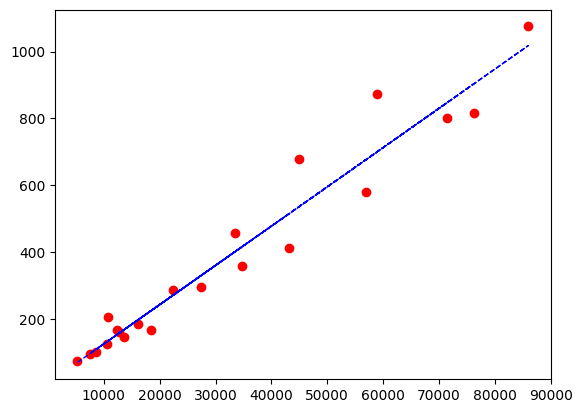

In [150]:
#Vamos a hacer el grafico de dispersión
import matplotlib.pyplot as plt
import numpy as np #Numpy sirve para trabajar con matrices, vectores, arrays, etc
plt.scatter(x,y,color="red")
plt.show

#Vamos a dibujar la linea de tendencia, y para ello vamos a usar numpy
z = np.polyfit(x,y,1) #polyfit ajusta los datos dentro de una función polinomial
#Hay otro método llamado poly1d que crea una clase unidimensional ()
h = np.poly1d(z)(x)
plt.plot(x,h,"b--", lw=1)
plt.show()

EXAMEN FINAL

Averiguar cuántas motocicletas tendré en el año 2036

In [157]:
from scipy.stats import linregress
import pandas as pd

motos = pd.read_csv(r"C:\Users\formacio\Downloads\Motocicletas gasolina.csv")

y = motos["Unidades"]
x = motos["Año"]

resultado = linregress(x, y)
a = resultado.slope
print("La pendiente es",round(a,4))
b = resultado.intercept
print("El valor de la intersección es",round(b,4))

r2 = resultado.rvalue**2
print("El coeficiente r2 es",round(r2*100,4),"%")

annodomini = 2036
prediccion = annodomini * a+b
print("El número de motocicletas estimadas para",annodomini,"es de",int(prediccion),"unidades")

La pendiente es 219.8286
El valor de la intersección es -437118.619
El coeficiente r2 es 96.7774 %
El número de motocicletas estimadas para 2036 es de 10452 unidades
